In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/intresting_data_to_visualize/cancer_b.csv',header=0)
df = df.iloc[:,2:]


9.71  -  12.12
12.12  -  14.53
14.53  -  16.94
16.94  -  19.35
19.35  -  21.76
21.76  -  24.17
24.17  -  26.58
26.58  -  28.99
28.99  -  31.4
31.4  -  33.81
--------------
43.79  -  50.871
50.871  -  57.952
57.952  -  65.033
65.033  -  72.114
72.114  -  79.195
79.195  -  86.276
86.276  -  93.357
93.357  -  100.438
100.438  -  107.519
107.519  -  114.6
--------------


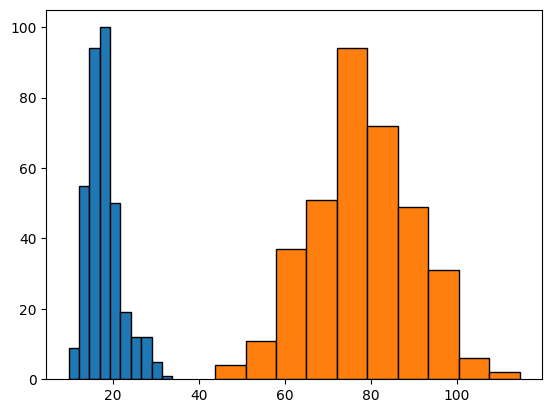

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/intresting_data_to_visualize/cancer_b.csv',header=0)
df = df.iloc[:,2:]

bins = 10
current_column = df.iloc[:,0]
# plt.hist(current_column, bins=10, edgecolor='black')

def getrange(current_column):
    plt.hist(current_column, bins=10, edgecolor='black')
    max = np.max(current_column)
    min = np.min(current_column)
    limit = max-min
    offset = limit/bins
    for i in range(bins):
        print(round(min,4),' - ',round(min+offset,4))
        min = min+offset
    print("--------------")

getrange(df.iloc[:,1])
getrange(df.iloc[:,2])


In [1]:
import pandas as pd
import numpy as np
import itertools

# Load your dataset
df = pd.read_csv('data/intresting_data_to_visualize/cancer_b.csv', header=0)
df = df.iloc[:, 2:]  # ignore first 2 columns if needed

# Function to get the intersection % between two columns
def intersection_percentage(col1, col2):
    # Drop NA values just in case
    x = df[col1].dropna()
    y = df[col2].dropna()

    # Find ranges
    min_x, max_x = x.min(), x.max()
    min_y, max_y = y.min(), y.max()

    # Find intersection range
    inter_min = max(min_x, min_y)
    inter_max = min(max_x, max_y)

    if inter_min >= inter_max:
        return 0  # No overlap

    # Count values lying within intersection
    in_x = x[(x >= inter_min) & (x <= inter_max)]
    in_y = y[(y >= inter_min) & (y <= inter_max)]

    # Combine both sets
    total_values = len(x) + len(y)
    total_in_range = len(in_x) + len(in_y)

    # Percentage of values in the intersection range
    return (total_in_range / total_values) * 100

# Calculate for all column pairs
results = []
columns = df.columns

for col1, col2 in itertools.combinations(columns, 2):
    percent = intersection_percentage(col1, col2)
    results.append({
        'Column 1': col1,
        'Column 2': col2,
        '% in Intersection': round(percent, 2)
    })

# Create summary DataFrame
intersection_df = pd.DataFrame(results)
print(intersection_df)

# Optional: save to CSV
intersection_df.to_csv('intersection_percentages.csv', index=False)



                   Column 1                   Column 2  % in Intersection
0             Radius (mean)             Texture (mean)              72.55
1             Radius (mean)           Perimeter (mean)               0.00
2             Radius (mean)                Area (mean)               0.00
3             Radius (mean)          Smoothness (mean)               0.00
4             Radius (mean)         Compactness (mean)               0.00
..                      ...                        ...                ...
430       Concavity (worst)           Symmetry (worst)              69.89
431       Concavity (worst)  Fractal dimension (worst)              67.23
432  Concave points (worst)           Symmetry (worst)               0.98
433  Concave points (worst)  Fractal dimension (worst)              85.29
434        Symmetry (worst)  Fractal dimension (worst)               0.00

[435 rows x 3 columns]


In [1]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from reportlab.pdfgen import canvas
from reportlab.lib.pagesizes import A4
from reportlab.lib.utils import ImageReader
import io

# Load data
df = pd.read_csv('data/intresting_data_to_visualize/cancer_b.csv', header=0)
df = df.iloc[:, 2:]  # skip non-numeric metadata columns

# Function: intersection % between two columns
def intersection_percentage(col1, col2):
    x = df[col1].dropna()
    y = df[col2].dropna()

    min_x, max_x = x.min(), x.max()
    min_y, max_y = y.min(), y.max()

    inter_min = max(min_x, min_y)
    inter_max = min(max_x, max_y)

    if inter_min >= inter_max:
        return 0, inter_min, inter_max

    in_x = x[(x >= inter_min) & (x <= inter_max)]
    in_y = y[(y >= inter_min) & (y <= inter_max)]

    total_values = len(x) + len(y)
    total_in_range = len(in_x) + len(in_y)
    percent = (total_in_range / total_values) * 100

    return percent, inter_min, inter_max


# Collect results
results = []
columns = df.columns

for col1, col2 in itertools.combinations(columns, 2):
    percent, inter_min, inter_max = intersection_percentage(col1, col2)
    if percent > 0:
        results.append({
            'Column 1': col1,
            'Column 2': col2,
            '% in Intersection': round(percent, 2),
            'Intersection Range': f"{inter_min:.3f} - {inter_max:.3f}"
        })

# Convert to DataFrame
intersection_df = pd.DataFrame(results)
print(intersection_df)

# --- Create PDF with Venn diagrams ---
pdf_path = "intersection_venn_report.pdf"
c = canvas.Canvas(pdf_path, pagesize=A4)
width, height = A4

for _, row in intersection_df.iterrows():
    col1, col2 = row['Column 1'], row['Column 2']
    percent = row['% in Intersection']
    inter_range = row['Intersection Range']

    # Get sets for plotting
    x = df[col1].dropna()
    y = df[col2].dropna()

    min_x, max_x = x.min(), x.max()
    min_y, max_y = y.min(), y.max()
    inter_min = max(min_x, min_y)
    inter_max = min(max_x, max_y)

    in_x = set(x[(x >= inter_min) & (x <= inter_max)].index)
    in_y = set(y[(y >= inter_min) & (y <= inter_max)].index)

    # Make Venn diagram
    plt.figure(figsize=(4, 4))
    venn2(subsets=(len(x), len(y), len(in_x & in_y)),
          set_labels=(col1, col2))
    plt.title(f"{col1} vs {col2}\n{percent:.2f}% in intersection\nRange: {inter_range}")

    # Save Venn diagram as image in memory
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    plt.close()
    buf.seek(0)

    # Add to PDF
    img = ImageReader(buf)
    c.drawImage(img, 50, 150, width - 100, height - 200)
    c.setFont("Helvetica-Bold", 12)
    c.drawString(50, height - 50, f"{col1} vs {col2} ({percent:.2f}%)")
    c.showPage()

c.save()
print(f"\n✅ PDF created: {pdf_path}")


                   Column 1                   Column 2  % in Intersection  \
0             Radius (mean)             Texture (mean)              72.55   
1             Radius (mean)                  Area (se)              69.47   
2             Radius (mean)             Radius (worst)              99.02   
3             Radius (mean)            Texture (worst)              34.73   
4            Texture (mean)                  Area (se)              93.98   
..                      ...                        ...                ...   
156       Concavity (worst)     Concave points (worst)              80.53   
157       Concavity (worst)           Symmetry (worst)              69.89   
158       Concavity (worst)  Fractal dimension (worst)              67.23   
159  Concave points (worst)           Symmetry (worst)               0.98   
160  Concave points (worst)  Fractal dimension (worst)              85.29   

    Intersection Range  
0       9.710 - 17.850  
1       6.981 - 17.850  
